In [53]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8

In [2]:
input_file = f'../../results/barseq/combined_all-reads_241011.csv'
df = pd.read_csv(input_file)

In [3]:
df.head()

,k3,pkr,pkr_bc,0hr,12hr,16hr,20hr,0hr_norm,12hr_norm,16hr_norm,20hr_norm,0hr_-log2fc,12hr_-log2fc,16hr_-log2fc,20hr_-log2fc,auc
0,K3Δ58,PKR-A479V,CACATAAATTCAAAAGTCCTTTGTTA,252.0,88.0,37.0,62.0,0.000088,0.000047,0.000031,0.000037,0.0,0.909591,1.519668,1.232492,3.045505
1,K3Δ58,PKR-A488D,AGCAGAACAGCTAAAAAAATTAGAGC,432.0,138.0,53.0,15.0,0.000150,0.000073,0.000044,0.000009,0.0,1.038105,1.778809,4.057405,4.845617
2,K3Δ58,PKR-A488D,ATAGCAACTAACAATCTTATTATCCA,210.0,67.0,24.0,78.0,0.000073,0.000036,0.000020,0.000047,0.0,1.039899,1.881125,0.638251,3.240149
3,K3Δ58,PKR-A488D,CAATAAATAGAGAATGCTTTTACAAC,80.0,25.0,8.0,0.0,0.000028,0.000013,0.000007,0.000000,0.0,1.069814,2.073770,8.146046,7.216607
4,K3Δ58,PKR-A488D,CTTATAAAAATTAAGGGCTTTTACAT,291.0,84.0,68.0,57.0,0.000101,0.000045,0.000056,0.000034,0.0,1.184300,0.849254,1.561393,2.814251


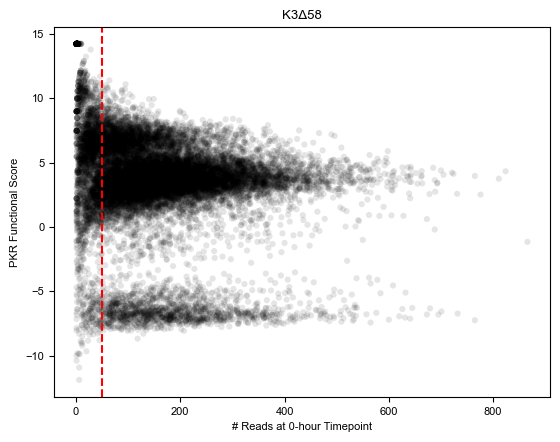

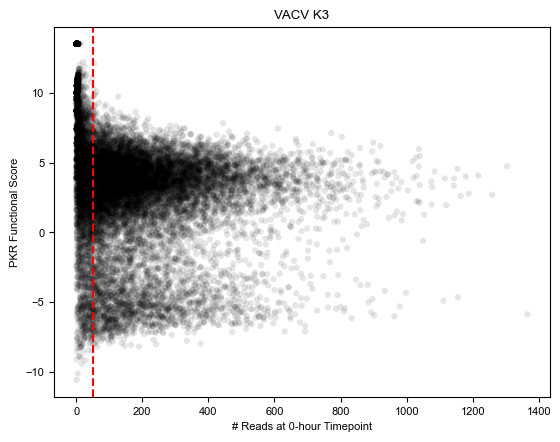

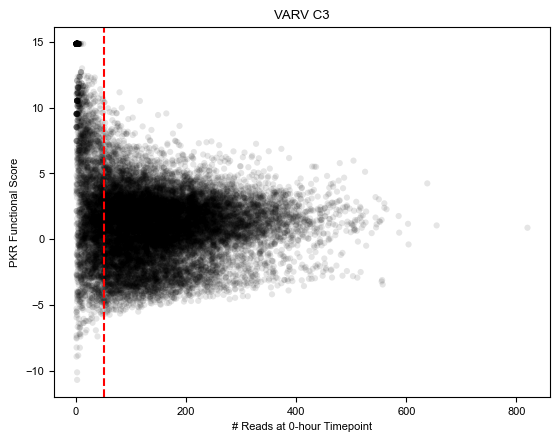

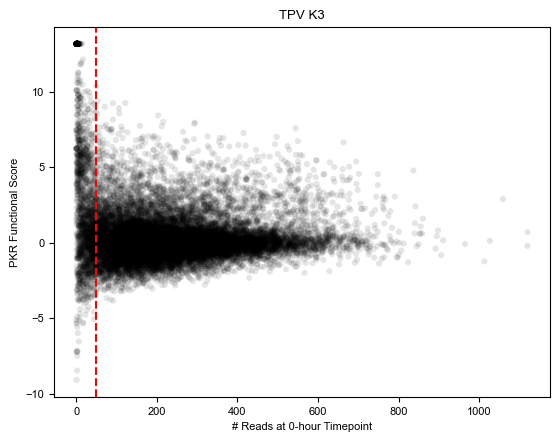

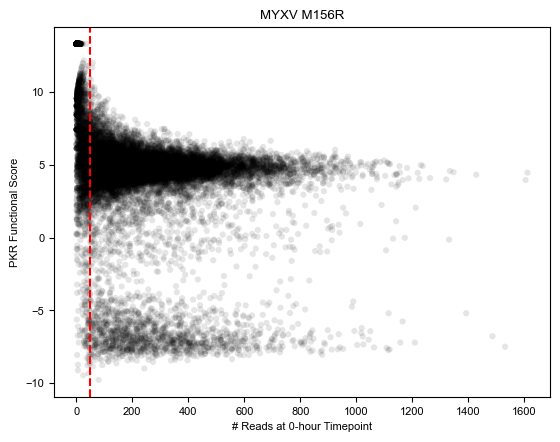

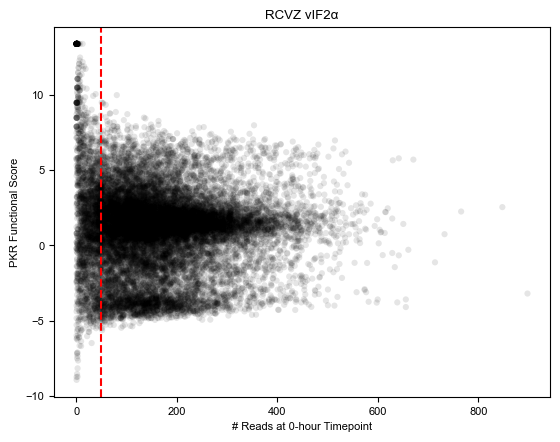

In [57]:
k3_order = ['K3Δ58', 'VACV K3', 'VARV C3', 'TPV K3', 'MYXV M156R', 'RCVZ vIF2α']

for k3 in k3_order:
    ax = df.query('k3 == @k3').plot.scatter(
        x='0hr',
        y='auc',
        c='black',
        alpha=.1,
        edgecolors='none', # remove marker outline,
    )
    ax.set_xlabel('# Reads at 0-hour Timepoint')
    ax.set_ylabel(f'PKR Functional Score')  # Keep a consistent y-label
    ax.set_title(f'{k3}')  # Move k3 label to title for clarity
    ax.axvline(x=50, color='red', linestyle='--')

    img_file = f'../../img/read-threshold/{k3}_read-threshold.png'
    plt.savefig(img_file, bbox_inches='tight', format='png', transparent=True)

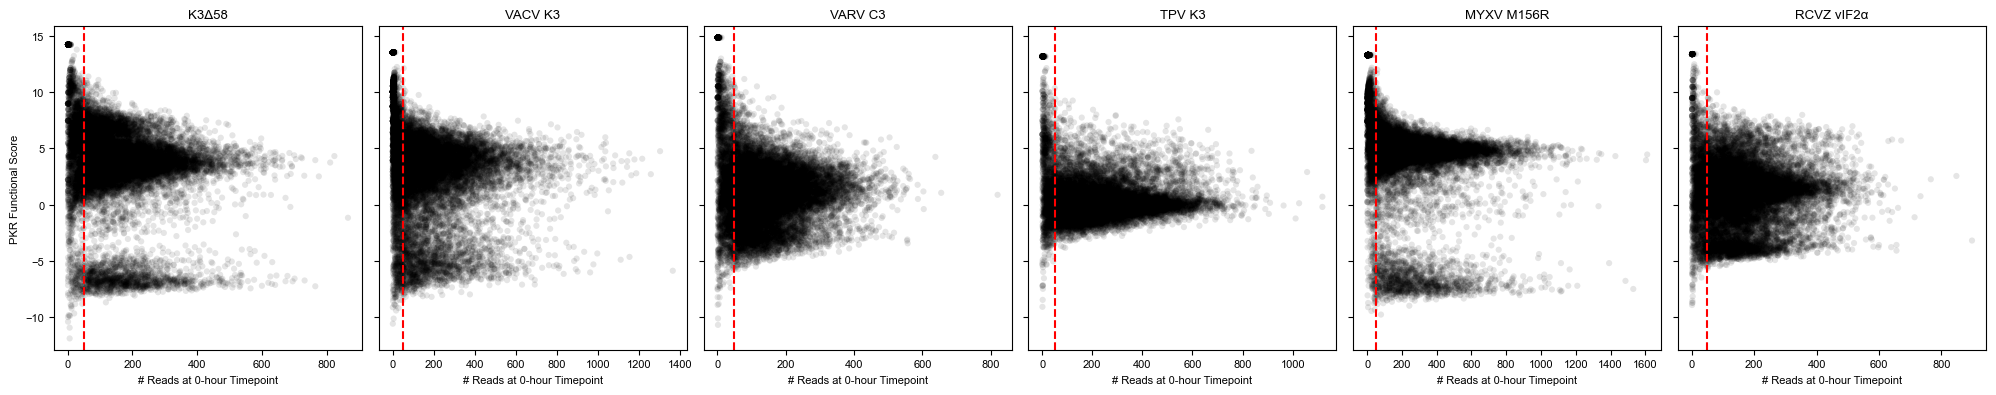

In [56]:
k3_order = ['K3Δ58', 'VACV K3', 'VARV C3', 'TPV K3', 'MYXV M156R', 'RCVZ vIF2α']

fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20, 4), sharey=True)

# set ymin ymax range
ymin = sorted(df.auc.unique().tolist())[1] -1
ymax = df.auc.max() + 1

for ax,k3 in zip(axes, k3_order):
    df.query('k3 == @k3').plot.scatter(
        x='0hr',
        y='auc',
        c='black',
        alpha=.1,
        edgecolors='none', # remove marker outline,
        ax=ax
    )
    ax.set_xlabel('# Reads at 0-hour Timepoint')
    ax.set_ylabel(f'PKR Functional Score')  # Keep a consistent y-label
    ax.set_title(f'{k3}')  # Move k3 label to title for clarity
    ax.axvline(x=50, color='red', linestyle='--')
    ax.set_ylim(ymin, ymax)


plt.tight_layout()
img_file = '../../img/read-threshold/read-threshold_all.svg'
fig.savefig(img_file, bbox_inches='tight', format='svg', transparent=True)
img_file = '../../img/read-threshold/read-threshold_all.png'
fig.savefig(img_file, bbox_inches='tight', format='png', transparent=True)
plt.show()

In [48]:
ymax

14.847293656097015